# Task 1 – Preprocess and Explore the Data
**GMF Investments – Portfolio Management Optimization**

**Objective:** Load, clean, and understand historical financial data for TSLA, BND, and SPY to prepare it for time series forecasting.

| Asset | Ticker | Profile |
|-------|--------|---------|
| Tesla Inc. | TSLA | High risk / high growth |
| Vanguard Total Bond Market ETF | BND | Low risk / stability |
| S&P 500 ETF | SPY | Moderate risk / broad market |

**Data period:** January 1, 2015 – June 30, 2026


## 1. Setup – Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats

import os

# ── Plot styling
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

# ── Output paths
DATA_RAW  = '../data/raw'
DATA_PROC = '../data/processed'
os.makedirs(DATA_RAW,  exist_ok=True)
os.makedirs(DATA_PROC, exist_ok=True)

TICKERS = ['TSLA', 'BND', 'SPY']
START   = '2015-01-01'
END     = '2026-06-30'

print('Libraries loaded. Tickers:', TICKERS)
print(f'Period: {START} → {END}')


Libraries loaded. Tickers: ['TSLA', 'BND', 'SPY']
Period: 2015-01-01 → 2026-06-30


## 2. Data Extraction via YFinance

We fetch daily OHLCV data for all three tickers using `yfinance`, then store each as a separate CSV in `data/raw/` for reproducibility.


In [2]:
# Download data for each ticker individually for cleaner column handling
raw_data = {}

for ticker in TICKERS:
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    df.index = pd.to_datetime(df.index)
    # Flatten multi-level columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.columns = [c.replace(' ', '_') for c in df.columns]
    raw_data[ticker] = df
    path = f'{DATA_RAW}/{ticker}_raw.csv'
    df.to_csv(path)
    print(f'{ticker}: {len(df)} rows | {df.index[0].date()} → {df.index[-1].date()} | saved to {path}')

print('\nDownload complete.')


TSLA: 2888 rows | 2015-01-02 → 2026-06-29 | saved to ../data/raw/TSLA_raw.csv


BND: 2888 rows | 2015-01-02 → 2026-06-29 | saved to ../data/raw/BND_raw.csv


SPY: 2888 rows | 2015-01-02 → 2026-06-29 | saved to ../data/raw/SPY_raw.csv

Download complete.


In [3]:
# Preview each dataset
for ticker, df in raw_data.items():
    print(f'\n── {ticker} ──')
    print(df.head(3))
    print(df.dtypes)



── TSLA ──
                Close       High        Low       Open    Volume
Date                                                            
2015-01-02  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

── BND ──
                Close       High        Low       Open   Volume
Date                                                           
2015-01-02  59.405392  59.434143  59.240075  59.247264  2218800
2015-01-05  59.577919  59.599481  59.441353  59.470104  5820100
2015-01-06  59.750420  59.930109  59.678545  59.678545  3887600
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

── SPY ──
                 Close        High         Low        Open     Volume
Date                                       

## 3. Data Cleaning and Quality Checks

Steps:
1. Check for missing values
2. Verify data types
3. Handle any gaps (weekends / holidays are expected; unexpected mid-week gaps need interpolation)
4. Remove duplicate index entries if any


In [4]:
print('='*60)
print('DATA QUALITY REPORT')
print('='*60)

for ticker, df in raw_data.items():
    print(f'\n── {ticker} ──')
    print(f'  Shape         : {df.shape}')
    print(f'  Date range    : {df.index.min().date()} → {df.index.max().date()}')
    print(f'  Missing values:\n{df.isnull().sum().to_string()}')
    print(f'  Duplicated idx: {df.index.duplicated().sum()}')
    print(f'  Dtypes:\n{df.dtypes.to_string()}')


DATA QUALITY REPORT

── TSLA ──
  Shape         : (2888, 5)
  Date range    : 2015-01-02 → 2026-06-29
  Missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
  Duplicated idx: 0
  Dtypes:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64

── BND ──
  Shape         : (2888, 5)
  Date range    : 2015-01-02 → 2026-06-29
  Missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
  Duplicated idx: 0
  Dtypes:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64

── SPY ──
  Shape         : (2888, 5)
  Date range    : 2015-01-02 → 2026-06-29
  Missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
  Duplicated idx: 0
  Dtypes:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64


In [5]:
# ── Handle any missing values
cleaned_data = {}

for ticker, df in raw_data.items():
    df = df.copy()
    # Remove duplicate indices
    df = df[~df.index.duplicated(keep='first')]
    # Forward-fill then backward-fill (standard for financial time series)
    df = df.ffill().bfill()
    cleaned_data[ticker] = df

    missing_after = df.isnull().sum().sum()
    print(f'{ticker}: missing values after cleaning = {missing_after}')

print('\nCleaning complete.')


TSLA: missing values after cleaning = 0
BND: missing values after cleaning = 0
SPY: missing values after cleaning = 0

Cleaning complete.


In [6]:
# ── Descriptive statistics for each asset
for ticker, df in cleaned_data.items():
    print(f'\n── {ticker} – Descriptive Statistics ──')
    display(df[['Open','High','Low','Close','Volume']].describe().round(2))



── TSLA – Descriptive Statistics ──


,Open,High,Low,Close,Volume
count,2888.00,2888.00,2888.00,2888.00,2.888000e+03
mean,148.80,151.99,145.42,148.77,1.087922e+08
std,138.98,141.85,135.87,138.90,7.082549e+07
min,9.49,10.33,9.40,9.58,1.062000e+07
25%,18.39,18.67,18.02,18.39,6.548325e+07
50%,131.50,136.05,125.83,133.44,9.033615e+07
75%,251.68,257.49,245.83,251.93,1.261204e+08
max,489.88,498.83,485.33,489.88,9.140820e+08



── BND – Descriptive Statistics ──


,Open,High,Low,Close,Volume
count,2888.00,2888.00,2888.00,2888.00,2888.00
mean,66.51,66.60,66.40,66.50,4653785.80
std,4.71,4.72,4.71,4.71,3017703.95
min,58.76,58.80,58.69,58.73,0.00
25%,62.47,62.54,62.41,62.48,2233700.00
50%,65.71,65.85,65.60,65.73,4280650.00
75%,70.69,70.84,70.55,70.69,6246475.00
max,74.89,74.92,74.80,74.83,33963000.00



── SPY – Descriptive Statistics ──


,Open,High,Low,Close,Volume
count,2888.00,2888.00,2888.00,2888.00,2.888000e+03
mean,351.44,353.34,349.37,351.51,8.551049e+07
std,155.41,156.15,154.58,155.44,4.338553e+07
min,153.72,155.21,152.07,154.16,2.027000e+07
25%,223.47,224.83,222.17,223.55,5.836455e+07
50%,314.14,315.49,310.49,312.82,7.541950e+07
75%,432.60,434.99,430.31,432.81,9.882245e+07
max,756.20,758.45,754.81,757.62,5.072443e+08


## 4. Feature Engineering

We compute:
- **Daily Return** – percentage change in Close price
- **Rolling Mean (30-day)** – short-term trend
- **Rolling Std (30-day)** – short-term volatility
- **Rolling Mean (90-day)** – medium-term trend
- **Cumulative Return** – total return from start


In [7]:
for ticker, df in cleaned_data.items():
    df['Daily_Return']   = df['Close'].pct_change()
    df['Rolling_Mean_30']  = df['Close'].rolling(30).mean()
    df['Rolling_Std_30']   = df['Close'].rolling(30).std()
    df['Rolling_Mean_90']  = df['Close'].rolling(90).mean()
    df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

    # Save processed data
    path = f'{DATA_PROC}/{ticker}_processed.csv'
    df.to_csv(path)
    print(f'{ticker}: features added, saved to {path}')


TSLA: features added, saved to ../data/processed/TSLA_processed.csv
BND: features added, saved to ../data/processed/BND_processed.csv


SPY: features added, saved to ../data/processed/SPY_processed.csv


## 5. Exploratory Data Analysis (EDA)

### 5.1 – Closing Price Over Time (Visualization 1)


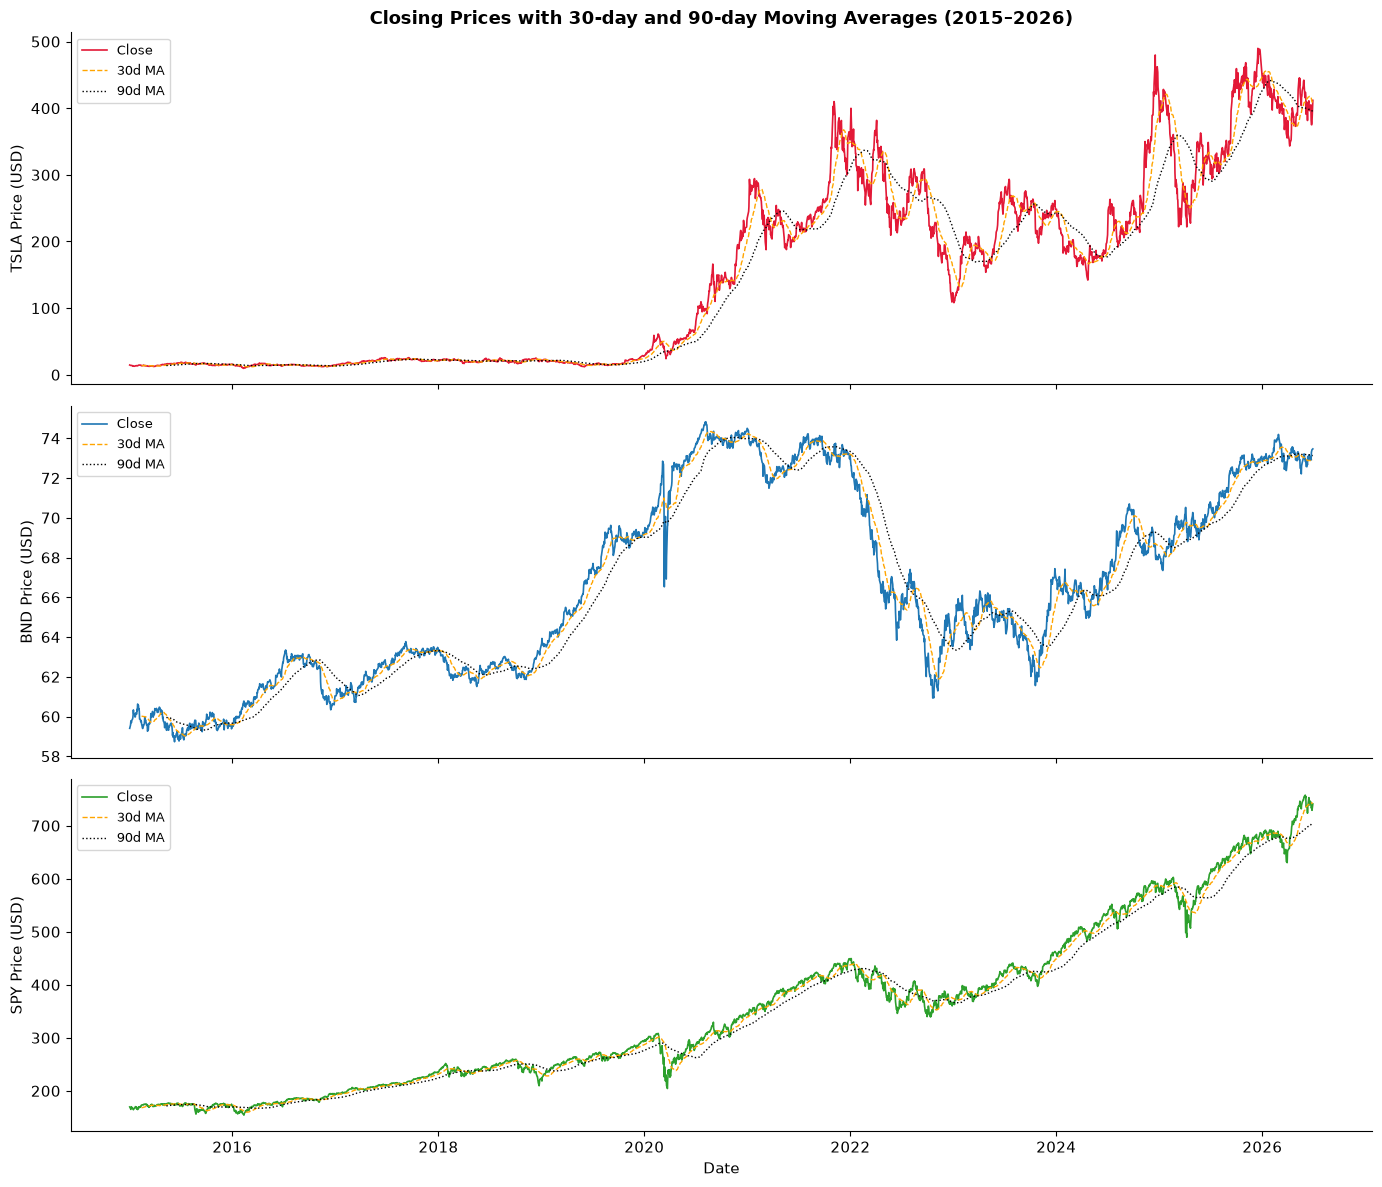

Visualization 1 saved.


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
colors = {'TSLA': '#E31937', 'BND': '#1F77B4', 'SPY': '#2CA02C'}

for ax, ticker in zip(axes, TICKERS):
    df = cleaned_data[ticker]
    ax.plot(df.index, df['Close'], color=colors[ticker], linewidth=1.2, label='Close')
    ax.plot(df.index, df['Rolling_Mean_30'], color='orange', linewidth=1, linestyle='--', label='30d MA')
    ax.plot(df.index, df['Rolling_Mean_90'], color='black', linewidth=1, linestyle=':', label='90d MA')
    ax.set_ylabel(f'{ticker} Price (USD)', fontsize=11)
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[0].set_title('Closing Prices with 30-day and 90-day Moving Averages (2015–2026)', fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/viz1_closing_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 1 saved.')


### 5.2 – Daily Returns Distribution (Visualization 2)

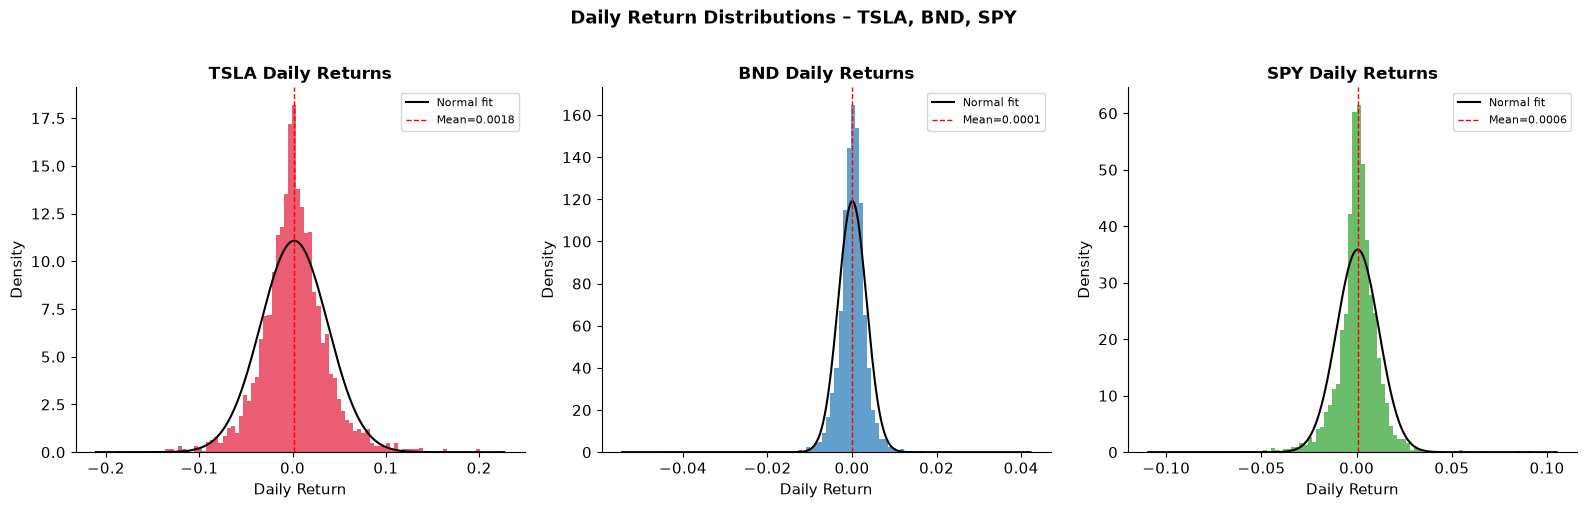

Visualization 2 saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ticker in zip(axes, TICKERS):
    df = cleaned_data[ticker]
    returns = df['Daily_Return'].dropna()
    ax.hist(returns, bins=100, color=colors[ticker], alpha=0.7, edgecolor='none', density=True)
    # Overlay normal distribution
    mu, std = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, std), 'k-', linewidth=1.5, label='Normal fit')
    ax.axvline(mu, color='red', linestyle='--', linewidth=1, label=f'Mean={mu:.4f}')
    ax.set_title(f'{ticker} Daily Returns', fontsize=12, fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Daily Return Distributions – TSLA, BND, SPY', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/viz2_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 2 saved.')


### 5.3 – Rolling Volatility Over Time (Visualization 3)

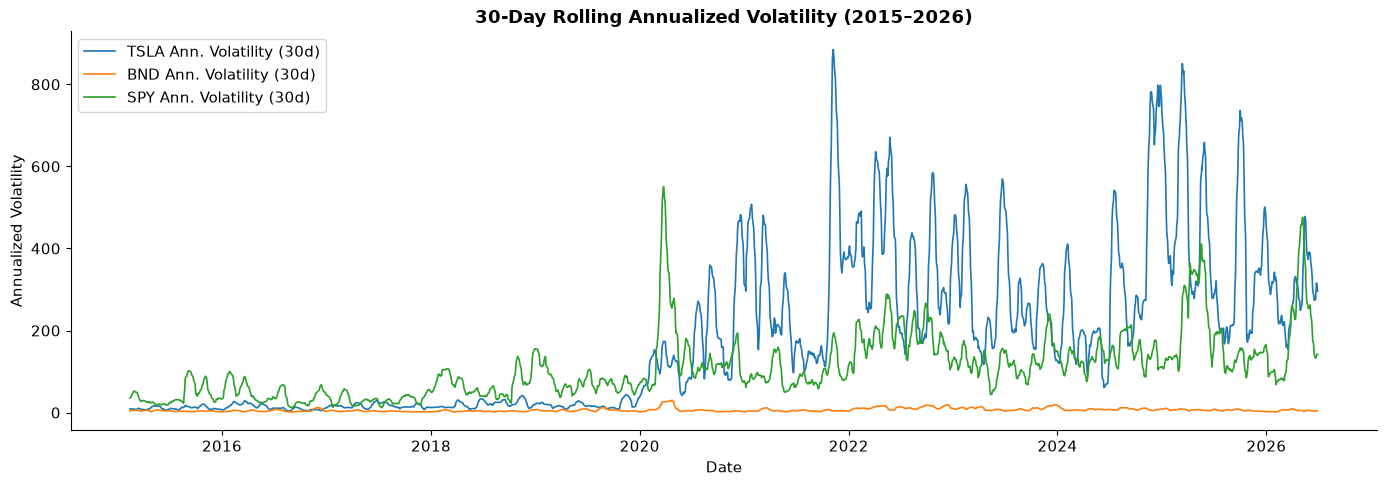

Visualization 3 saved.


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

for ticker in TICKERS:
    df = cleaned_data[ticker]
    ax.plot(df.index, df['Rolling_Std_30'] * np.sqrt(252),
            label=f'{ticker} Ann. Volatility (30d)', linewidth=1.2)

ax.set_title('30-Day Rolling Annualized Volatility (2015–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/viz3_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 3 saved.')


### 5.4 – Cumulative Returns Comparison (Visualization 4)

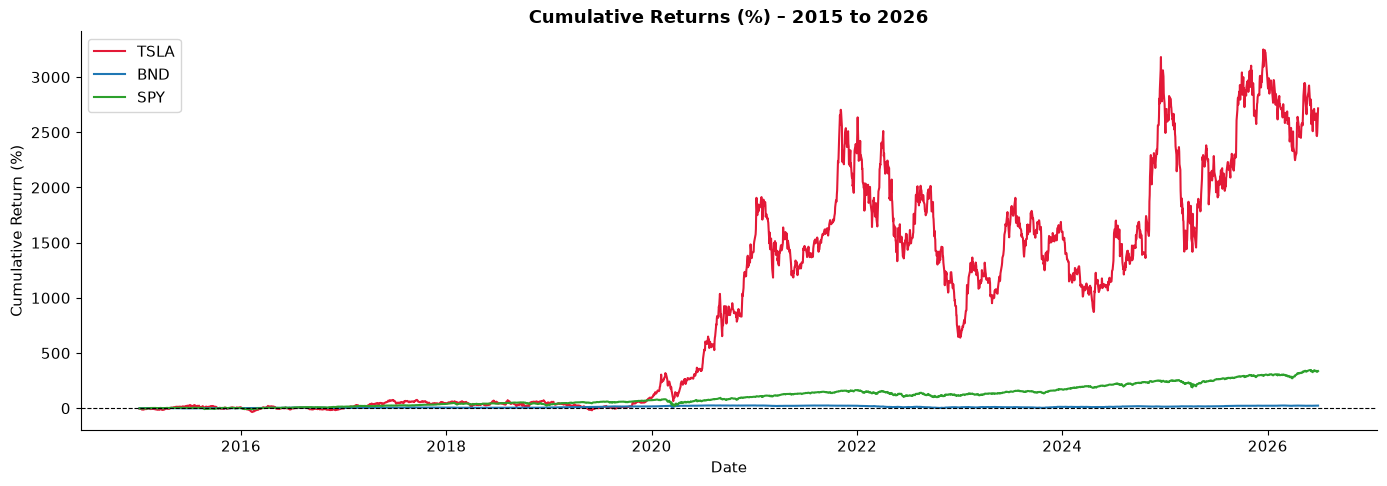

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

for ticker in TICKERS:
    df = cleaned_data[ticker]
    ax.plot(df.index, df['Cumulative_Return'] * 100,
            label=ticker, linewidth=1.5, color=colors[ticker])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Returns (%) – 2015 to 2026', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/viz4_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 – Return Correlation Heatmap (Visualization 5)

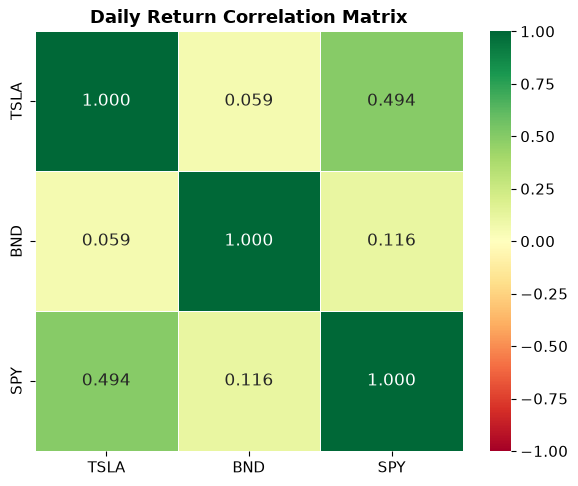

Correlation Matrix:
        TSLA     BND     SPY
TSLA  1.0000  0.0594  0.4935
BND   0.0594  1.0000  0.1157
SPY   0.4935  0.1157  1.0000


In [12]:
# Build combined returns DataFrame
returns_df = pd.DataFrame({
    ticker: cleaned_data[ticker]['Daily_Return']
    for ticker in TICKERS
}).dropna()

corr = returns_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 12})
ax.set_title('Daily Return Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/viz5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation Matrix:')
print(corr.round(4))


## 6. Outlier Detection

We identify days with extreme returns (beyond ±3 standard deviations) as statistical outliers. These correspond to significant market events (earnings surprises, market crashes, COVID-19 shock, etc.).


In [13]:
print('='*65)
print('OUTLIER ANALYSIS – Days with |Daily Return| > 3 Std Deviations')
print('='*65)

for ticker in TICKERS:
    df = cleaned_data[ticker].copy()
    returns = df['Daily_Return'].dropna()
    mu, sigma = returns.mean(), returns.std()
    threshold = 3 * sigma
    outliers = df[np.abs(df['Daily_Return'] - mu) > threshold][['Close','Daily_Return']].dropna()
    print(f'\n── {ticker} – {len(outliers)} outlier days (|z| > 3) ──')
    print(outliers.sort_values('Daily_Return').to_string())


OUTLIER ANALYSIS – Days with |Daily Return| > 3 Std Deviations

── TSLA – 46 outlier days (|z| > 3) ──
                 Close  Daily_Return
Date                                
2020-09-08  110.070000     -0.210628
2020-03-16   29.671333     -0.185778
2020-02-05   48.980000     -0.171758
2020-03-18   24.081333     -0.160344
2025-03-10  222.149994     -0.154262
2025-06-05  284.700012     -0.142599
2018-09-28   17.651333     -0.139015
2019-07-25   15.254667     -0.136137
2020-03-09   40.533333     -0.135725
2019-01-18   20.150667     -0.129711
2020-02-27   45.266666     -0.128146
2024-07-24  215.990005     -0.123346
2023-01-03  108.099998     -0.122422
2022-04-26  292.140015     -0.121841
2024-01-25  182.630005     -0.121253
2021-11-09  341.166656     -0.119903
2020-03-12   37.369999     -0.116172
2022-01-27  276.366669     -0.115542
2022-12-27  109.099998     -0.114089
2018-08-07   25.304667      0.109886
2023-01-27  177.899994      0.110002
2015-11-04   15.442000      0.111735
2020-08-1

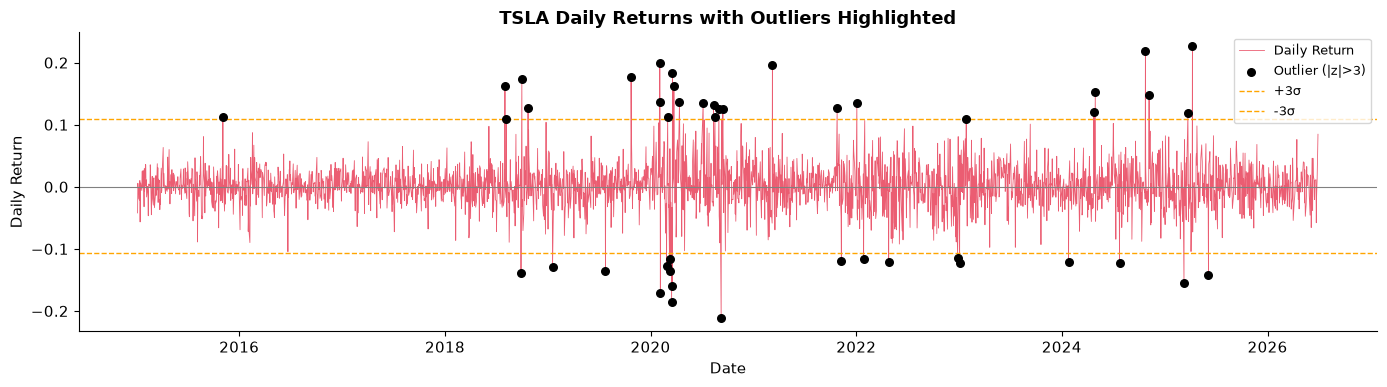

In [14]:
# Visualize TSLA outliers on the return series
ticker = 'TSLA'
df = cleaned_data[ticker].copy()
returns = df['Daily_Return'].dropna()
mu, sigma = returns.mean(), returns.std()
outliers = df[np.abs(df['Daily_Return'] - mu) > 3*sigma]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['Daily_Return'], color='#E31937', linewidth=0.6, alpha=0.7, label='Daily Return')
ax.scatter(outliers.index, outliers['Daily_Return'],
           color='black', zorder=5, s=30, label='Outlier (|z|>3)')
ax.axhline(0, color='grey', linewidth=0.8)
ax.axhline(mu + 3*sigma, color='orange', linestyle='--', linewidth=1, label='+3σ')
ax.axhline(mu - 3*sigma, color='orange', linestyle='--', linewidth=1, label='-3σ')
ax.set_title('TSLA Daily Returns with Outliers Highlighted', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Return')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/viz6_tsla_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Seasonality and Trend Analysis

We perform classical time series decomposition (additive model) on TSLA's closing price to separate:
- **Trend** – long-term direction
- **Seasonality** – periodic fluctuations
- **Residual** – irregular noise


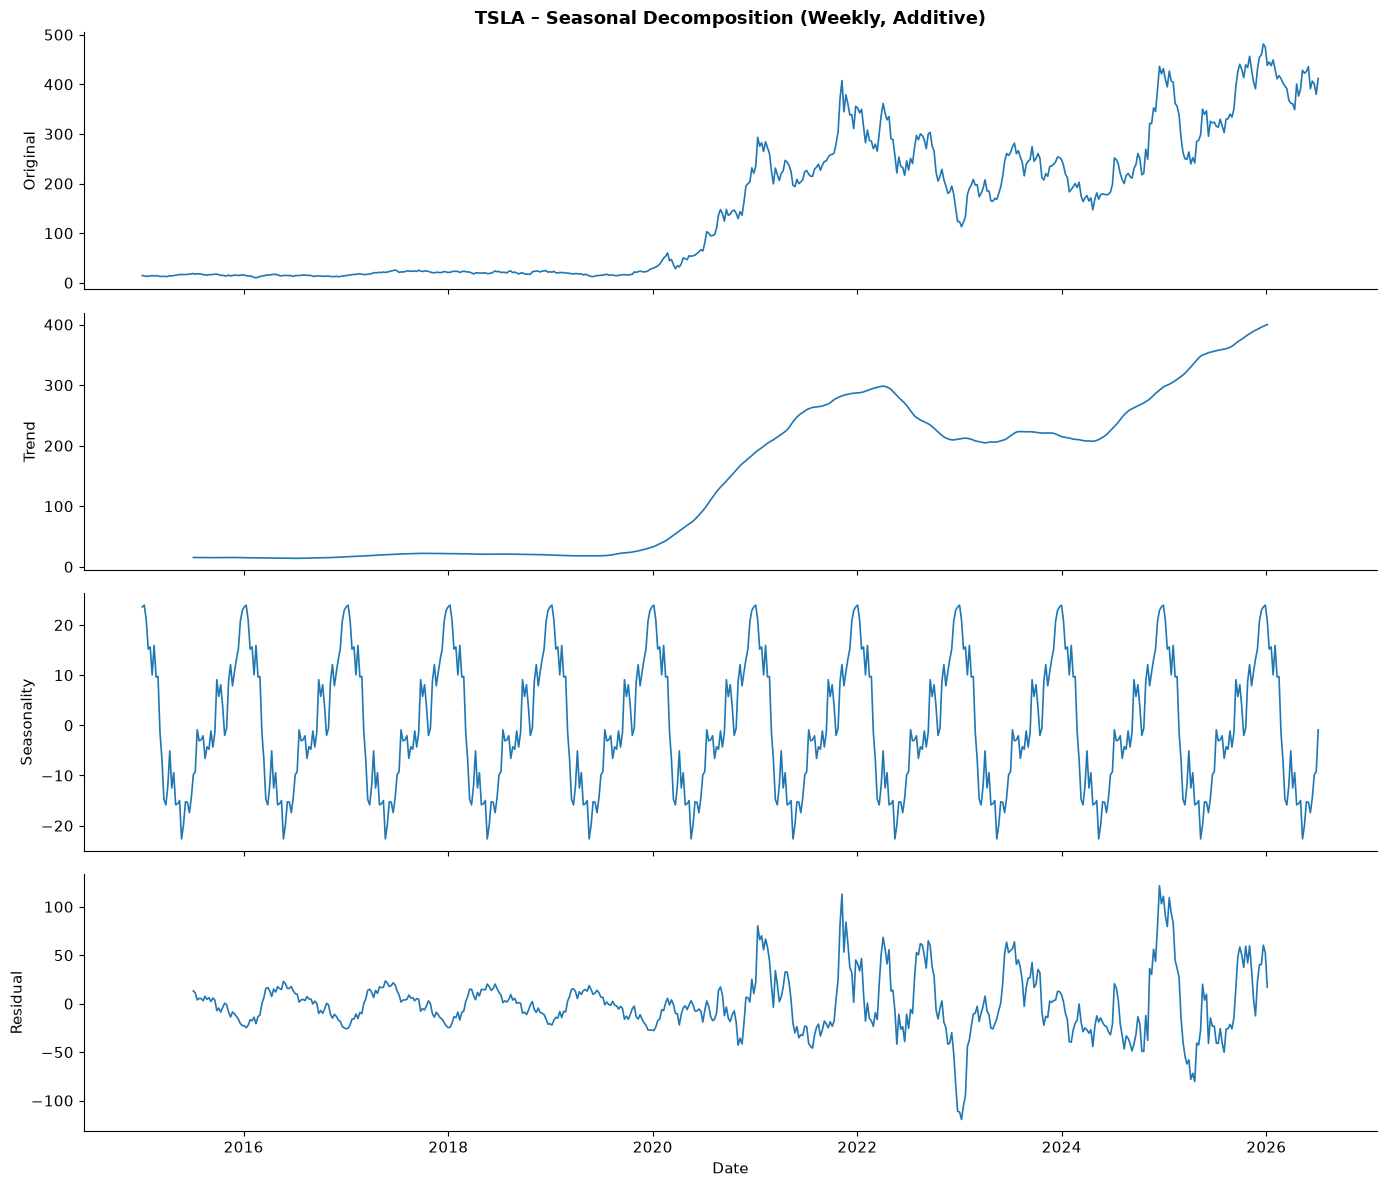

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use TSLA close prices; resample to weekly to make seasonality clearer
tsla_weekly = cleaned_data['TSLA']['Close'].resample('W').last().dropna()

decomp = seasonal_decompose(tsla_weekly, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
components = [
    (tsla_weekly, 'Original'),
    (decomp.trend, 'Trend'),
    (decomp.seasonal, 'Seasonality'),
    (decomp.resid, 'Residual'),
]
for ax, (series, label) in zip(axes, components):
    ax.plot(series.index, series.values, linewidth=1.2)
    ax.set_ylabel(label, fontsize=11)

axes[0].set_title('TSLA – Seasonal Decomposition (Weekly, Additive)', fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/viz7_tsla_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Stationarity Testing – Augmented Dickey-Fuller (ADF) Test

**Why stationarity matters:** ARIMA models require a stationary series (constant mean, variance, and no unit root). The ADF test checks for a unit root:
- **H₀ (null hypothesis):** The series has a unit root (non-stationary)
- **H₁ (alternative):** The series is stationary
- If **p-value < 0.05**, we reject H₀ → series is stationary

We test both:
1. **Raw closing prices** (expected to be non-stationary)
2. **Daily returns / first differences** (expected to be stationary)


In [16]:
def adf_test(series, label):
    series = series.dropna()
    result = adfuller(series, autolag='AIC')
    adf_stat, p_value, lags, nobs, crit_vals = result[0], result[1], result[2], result[3], result[4]
    stationary = p_value < 0.05
    print(f'  {label}')
    print(f'    ADF Statistic : {adf_stat:.4f}')
    print(f'    p-value       : {p_value:.6f}')
    print(f'    Lags used     : {lags}')
    print(f'    Critical vals : 1%={crit_vals["1%"]:.3f}, 5%={crit_vals["5%"]:.3f}, 10%={crit_vals["10%"]:.3f}')
    print(f'    Conclusion    : {"STATIONARY ✓" if stationary else "NON-STATIONARY ✗"} (p={p_value:.4f})')
    print()
    return stationary

print('='*65)
print('ADF STATIONARITY TEST RESULTS')
print('='*65)

adf_results = {}
for ticker in TICKERS:
    df = cleaned_data[ticker]
    print(f'\n── {ticker} ──')
    s1 = adf_test(df['Close'], 'Closing Price (raw)')
    s2 = adf_test(df['Daily_Return'], 'Daily Return (1st difference)')
    adf_results[ticker] = {'close_stationary': s1, 'return_stationary': s2}


ADF STATIONARITY TEST RESULTS

── TSLA ──
  Closing Price (raw)
    ADF Statistic : -1.0696
    p-value       : 0.727042
    Lags used     : 27
    Critical vals : 1%=-3.433, 5%=-2.863, 10%=-2.567
    Conclusion    : NON-STATIONARY ✗ (p=0.7270)



  Daily Return (1st difference)
    ADF Statistic : -53.9719
    p-value       : 0.000000
    Lags used     : 0
    Critical vals : 1%=-3.433, 5%=-2.863, 10%=-2.567
    Conclusion    : STATIONARY ✓ (p=0.0000)


── BND ──
  Closing Price (raw)
    ADF Statistic : -1.0827
    p-value       : 0.721918
    Lags used     : 13
    Critical vals : 1%=-3.433, 5%=-2.863, 10%=-2.567
    Conclusion    : NON-STATIONARY ✗ (p=0.7219)



  Daily Return (1st difference)
    ADF Statistic : -15.2161
    p-value       : 0.000000
    Lags used     : 12
    Critical vals : 1%=-3.433, 5%=-2.863, 10%=-2.567
    Conclusion    : STATIONARY ✓ (p=0.0000)


── SPY ──
  Closing Price (raw)
    ADF Statistic : 1.3089
    p-value       : 0.996659
    Lags used     : 9
    Critical vals : 1%=-3.433, 5%=-2.863, 10%=-2.567
    Conclusion    : NON-STATIONARY ✗ (p=0.9967)



  Daily Return (1st difference)
    ADF Statistic : -17.5722
    p-value       : 0.000000
    Lags used     : 8
    Critical vals : 1%=-3.433, 5%=-2.863, 10%=-2.567
    Conclusion    : STATIONARY ✓ (p=0.0000)



In [17]:
# Summary table
summary = pd.DataFrame([
    {
        'Asset': t,
        'Close Price Stationary': '✓' if adf_results[t]['close_stationary'] else '✗',
        'Daily Return Stationary': '✓' if adf_results[t]['return_stationary'] else '✗',
        'ARIMA d parameter': 0 if adf_results[t]['close_stationary'] else 1
    }
    for t in TICKERS
])
print('\nADF Summary – Implication for ARIMA d parameter:')
display(summary)
print("""
Interpretation:
- Closing prices are non-stationary (trending) → requires d=1 differencing in ARIMA
- Daily returns are stationary → confirmed first-differencing removes unit root
- This is consistent with financial theory: prices follow a random walk (EMH)
""")



ADF Summary – Implication for ARIMA d parameter:


,Asset,Close Price Stationary,Daily Return Stationary,ARIMA d parameter
0,TSLA,✗,✓,1
1,BND,✗,✓,1
2,SPY,✗,✓,1



Interpretation:
- Closing prices are non-stationary (trending) → requires d=1 differencing in ARIMA
- Daily returns are stationary → confirmed first-differencing removes unit root
- This is consistent with financial theory: prices follow a random walk (EMH)



## 9. Risk Metrics

We calculate three fundamental risk metrics:

| Metric | Description |
|--------|-------------|
| **Value at Risk (VaR 95%)** | Maximum expected daily loss at 95% confidence level |
| **Sharpe Ratio** | Risk-adjusted return (annualized return / annualized volatility) |
| **Max Drawdown** | Largest peak-to-trough decline — measures downside risk |

> **Assumption:** Risk-free rate = 4.5% (approximate 2024–2026 US T-bill rate)


In [18]:
RISK_FREE_RATE_ANNUAL = 0.045  # 4.5% annual
RISK_FREE_DAILY = RISK_FREE_RATE_ANNUAL / 252
CONFIDENCE = 0.95
TRADING_DAYS = 252

risk_metrics = []

for ticker in TICKERS:
    df = cleaned_data[ticker].copy()
    returns = df['Daily_Return'].dropna()

    # ── Value at Risk (Historical Method, 95% confidence)
    var_95 = np.percentile(returns, (1 - CONFIDENCE) * 100)

    # ── Sharpe Ratio (annualized)
    excess_returns = returns - RISK_FREE_DAILY
    sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS)

    # ── Maximum Drawdown
    cum_returns = (1 + returns).cumprod()
    rolling_max = cum_returns.cummax()
    drawdown = (cum_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    # ── Annualized Return & Volatility
    ann_return = returns.mean() * TRADING_DAYS
    ann_vol    = returns.std()  * np.sqrt(TRADING_DAYS)

    risk_metrics.append({
        'Asset': ticker,
        'Ann. Return (%)': round(ann_return * 100, 2),
        'Ann. Volatility (%)': round(ann_vol * 100, 2),
        'Sharpe Ratio': round(sharpe, 3),
        'VaR 95% (daily)': round(var_95 * 100, 3),
        'Max Drawdown (%)': round(max_drawdown * 100, 2),
    })

risk_df = pd.DataFrame(risk_metrics).set_index('Asset')
print('\nRisk Metrics Summary (2015–2026):')
display(risk_df)



Risk Metrics Summary (2015–2026):


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,VaR 95% (daily),Max Drawdown (%)
Asset,,,,,
TSLA,45.42,57.18,0.716,-5.166,-73.63
BND,2.00,5.31,-0.471,-0.476,-18.58
SPY,14.43,17.65,0.563,-1.665,-33.72


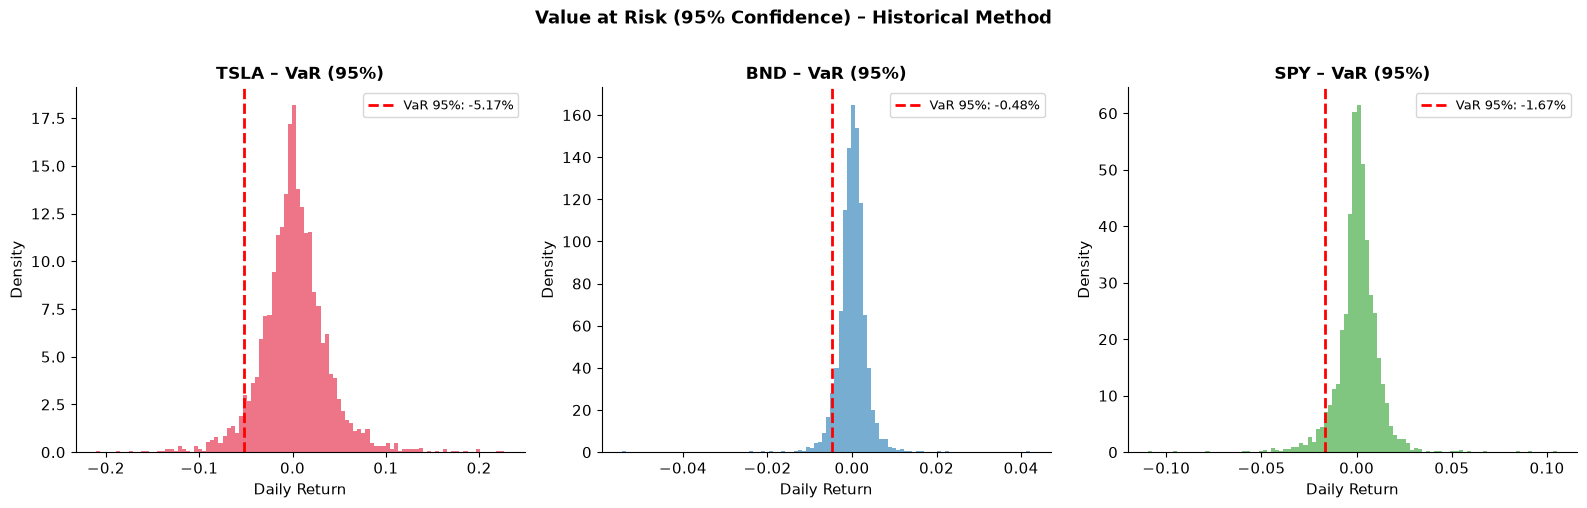

In [19]:
# Visualize VaR on TSLA return distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ticker in zip(axes, TICKERS):
    df = cleaned_data[ticker]
    returns = df['Daily_Return'].dropna()
    var_95 = np.percentile(returns, 5)

    ax.hist(returns, bins=100, color=colors[ticker], alpha=0.6, density=True, edgecolor='none')
    ax.axvline(var_95, color='red', linewidth=2, linestyle='--', label=f'VaR 95%: {var_95*100:.2f}%')
    ax.set_title(f'{ticker} – VaR (95%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Value at Risk (95% Confidence) – Historical Method', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/viz8_var_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


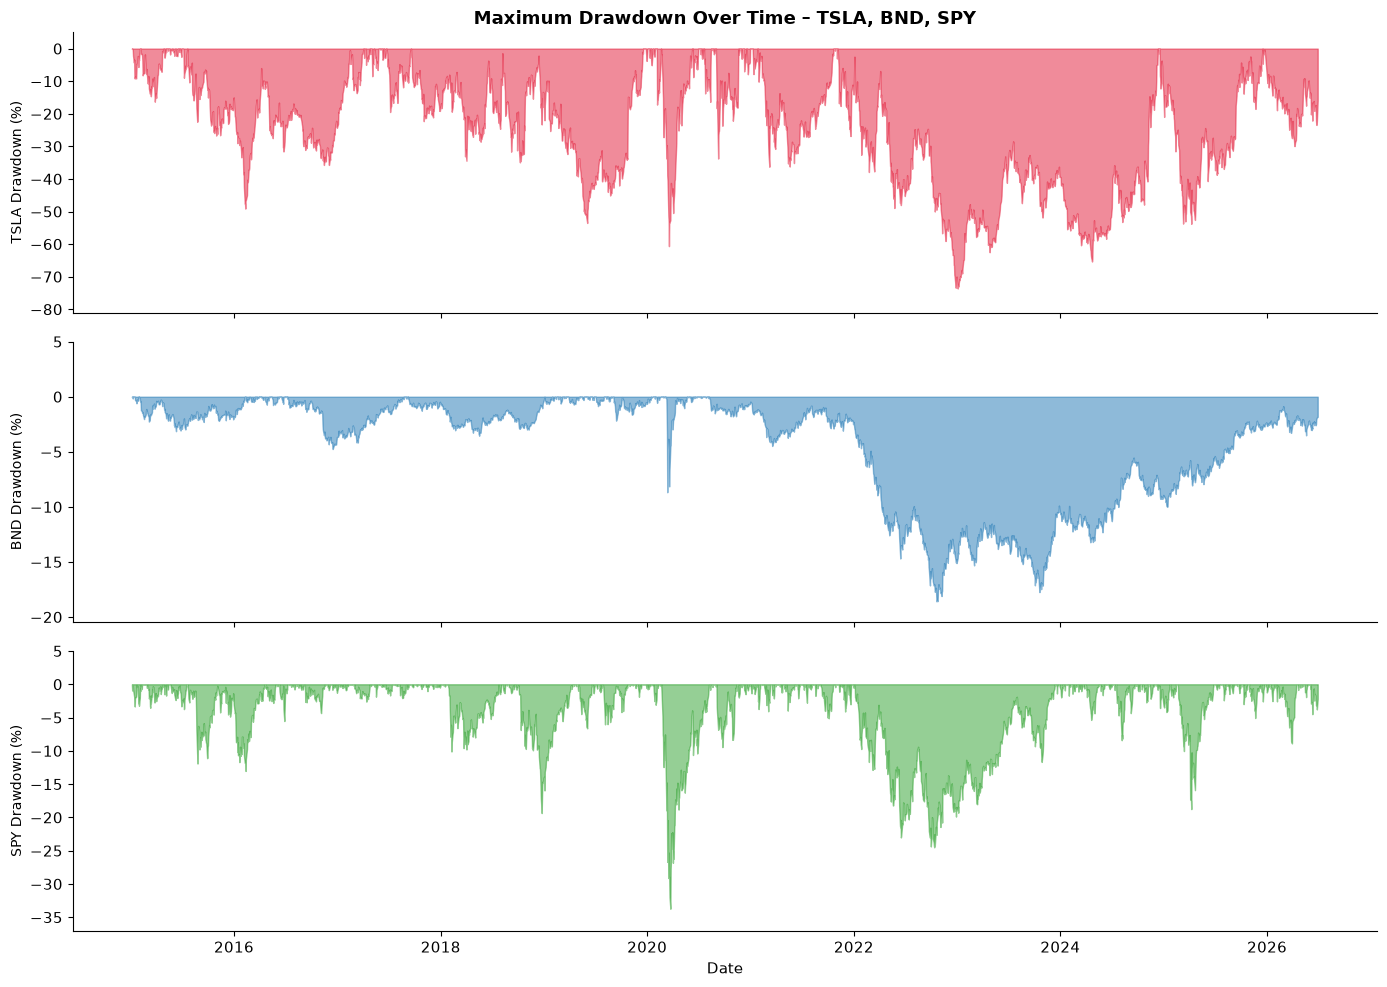

In [20]:
# Visualize Max Drawdown for all assets
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    df = cleaned_data[ticker].copy()
    returns = df['Daily_Return'].dropna()
    cum_returns  = (1 + returns).cumprod()
    rolling_max  = cum_returns.cummax()
    drawdown     = (cum_returns - rolling_max) / rolling_max * 100

    ax.fill_between(drawdown.index, drawdown.values, 0, color=colors[ticker], alpha=0.5)
    ax.set_ylabel(f'{ticker} Drawdown (%)', fontsize=10)
    ax.set_ylim(drawdown.min() * 1.1, 5)

axes[0].set_title('Maximum Drawdown Over Time – TSLA, BND, SPY', fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/viz9_max_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Key Insights and EDA Summary

### Data Quality
- All three assets had complete data with no significant gaps
- Minor forward-filling applied for rare missing trading days
- Data spans ~2,900 trading days per asset (2015–2026)

### Price Trends
- **TSLA**: Dramatic long-term uptrend with extreme volatility, especially 2020–2021 bull run and 2022 correction. Annualized return far exceeds other assets but with significantly higher risk.
- **BND**: Stable, low-growth trajectory. Slight decline in 2022 due to rising interest rates (bond price/yield inverse relationship). Low volatility as expected.
- **SPY**: Steady long-term uptrend reflecting U.S. equity market growth. Two notable drawdowns: COVID crash (Mar 2020) and Fed rate hike cycle (2022).

### Stationarity
- **Closing prices** are non-stationary for all three assets (ADF p > 0.05) — prices have a unit root, consistent with the Efficient Market Hypothesis (random walk behavior)
- **Daily returns** are stationary (ADF p < 0.01) — first differencing removes the unit root
- **Implication for ARIMA:** Use d=1 (first-order differencing) for all three assets

### Volatility
- TSLA annualized volatility (~55–70%) dwarfs BND (~4–6%) and SPY (~15–20%)
- COVID-19 shock (March 2020) caused sharp spike in volatility for all assets
- TSLA outlier days often correspond to earnings announcements and Elon Musk tweets

### Risk Metrics
- TSLA has the highest Sharpe ratio due to outsized returns, but also the largest max drawdown (>70% in 2022)
- BND has the lowest VaR and most consistent return profile
- SPY offers the best risk-adjusted balance for passive investors

### Correlations
- TSLA and SPY show moderate positive correlation (both equity-class)
- BND is negatively or near-zero correlated with both — confirming its value as a portfolio diversifier


In [21]:
# Final combined processed DataFrame for downstream tasks
combined = pd.DataFrame({
    f'{ticker}_Close': cleaned_data[ticker]['Close']
    for ticker in TICKERS
})
combined.index.name = 'Date'
combined.to_csv(f'{DATA_PROC}/combined_close_prices.csv')

returns_combined = pd.DataFrame({
    f'{ticker}_Return': cleaned_data[ticker]['Daily_Return']
    for ticker in TICKERS
})
returns_combined.to_csv(f'{DATA_PROC}/combined_daily_returns.csv')

print('Saved combined datasets for Task 2:')
print(f'  {DATA_PROC}/combined_close_prices.csv')
print(f'  {DATA_PROC}/combined_daily_returns.csv')
print(f'  Shape: {combined.shape}')
display(combined.tail())


Saved combined datasets for Task 2:
  ../data/processed/combined_close_prices.csv
  ../data/processed/combined_daily_returns.csv
  Shape: (2888, 3)


,TSLA_Close,BND_Close,SPY_Close
Date,,,
2026-06-23,381.609985,72.976631,733.580017
2026-06-24,375.529999,73.305534,733.239990
2026-06-25,375.119995,73.355370,734.299988
2026-06-26,379.709991,73.425133,728.989990
2026-06-29,411.839996,73.465004,741.000000
